# 02d — EDA: Đề xuất hành động

Phần 4/4 của EDA (tách từ `02_eda.ipynb` gốc — xem `docs/analysis/EDA_FINDINGS.md` cho phân tích đầy đủ, gồm so sánh độ lớn 3 đề xuất). Mỗi đề xuất tự build lại dữ liệu cần (không share state với file khác — 3 notebook trên).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # notebook vẫn hiện inline qua %matplotlib inline bên dưới
import matplotlib.pyplot as plt
from lunardate import LunarDate

from datathon import config
from datathon.ingestion import load_raw

%matplotlib inline

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

C_REV, C_COGS, C_GRAY, C_ACCENT = "#A32D2D", "#185FA5", "#888780", "#534AB7"
PALETTE = ["#185FA5", "#A32D2D", "#3B6D11", "#BA7517", "#534AB7", "#993556"]
AGE_ORDER = ["18-24", "25-34", "35-44", "45-54", "55+"]

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

print("DATA_RAW:", config.DATA_RAW)


DATA_RAW: /Users/lhoanghai_/Documents/Study/Dự án datathon2026/data/raw


In [2]:
import os
import trino

_trino_conn = trino.dbapi.connect(
    host=os.environ.get("TRINO_HOST", "localhost"),
    port=int(os.environ.get("TRINO_PORT", "8080")),
    user="notebook_02_eda",
    catalog="iceberg",
    schema="staging",
)
sales = pd.read_sql(
    "SELECT date AS \"Date\", revenue AS \"Revenue\", cogs AS \"COGS\" "
    "FROM mart_revenue_daily ORDER BY date",
    _trino_conn,
)
sales["Date"] = pd.to_datetime(sales["Date"])
assert len(sales) == 3833, f"mart_revenue_daily phải 3833 dòng, đang {len(sales)}"
orders = load_raw("orders")
items = load_raw("order_items")
products = load_raw("products")
customers = load_raw("customers")
geography = load_raw("geography")
promotions = load_raw("promotions")
returns = load_raw("returns")
payments = load_raw("payments")

for name, df in [("sales", sales), ("orders", orders), ("order_items", items),
                  ("products", products), ("customers", customers),
                  ("geography", geography), ("promotions", promotions),
                  ("returns", returns), ("payments", payments)]:
    print(f"{name:14s} {df.shape}")


sales          (3833, 3)
orders         (646945, 8)
order_items    (714669, 7)
products       (2412, 8)
customers      (121930, 7)
geography      (39948, 4)
promotions     (50, 10)
returns        (39939, 7)
payments       (646945, 4)


In [3]:
# customers đã có sẵn cột 'zip' (khác bản gốc chỉ usecols acquisition_channel/signup_date) ->
# drop trước khi merge để tránh đụng 'zip' đã có từ orders (tránh bị pandas tự suffix zip_x/zip_y).
customers_nozip = customers.drop(columns=["zip"])

li = (items
      .merge(orders, on="order_id", how="left")
      .merge(products, on="product_id", how="left")
      .merge(customers_nozip, on="customer_id", how="left")
      .merge(geography, on="zip", how="left")
      .merge(promotions, on="promo_id", how="left"))

li["line_revenue"] = li["quantity"] * li["unit_price"]
li["line_cogs"] = li["quantity"] * li["cogs"]
li["year"] = li["order_date"].dt.year
li["month"] = li["order_date"].dt.month
li = li[li["year"].between(2013, 2022)].copy()

chk = li.groupby(li["order_date"])["line_revenue"].sum()
sales_idx = sales.set_index("Date")["Revenue"]
diff = ((chk.reindex(sales_idx.index) - sales_idx).abs() / sales_idx).mean() * 100
print(f"Sanity check — sai lệch rebuilt (line_revenue) vs sales.csv: {diff:.3f}% (kỳ vọng ~0%)")
print(f"{len(li):,} dòng sau join, {li['customer_id'].nunique():,} khách")


Sanity check — sai lệch rebuilt (line_revenue) vs sales.csv: 0.000% (kỳ vọng ~0%)
677,662 dòng sau join, 89,063 khách


## Đề xuất 1 — Floor price = giá vốn

Tổng dòng order_items (toàn bộ lịch sử): 714,669 | dưới giá vốn: 133,052 (18.62%)
Margin thực tế: 13.80% (2.267 tỷ VND)
Margin nếu áp floor price = cogs: 16.15% (2.729 tỷ VND)
=> Margin tăng thêm: +2.36 điểm % , +0.462 tỷ VND


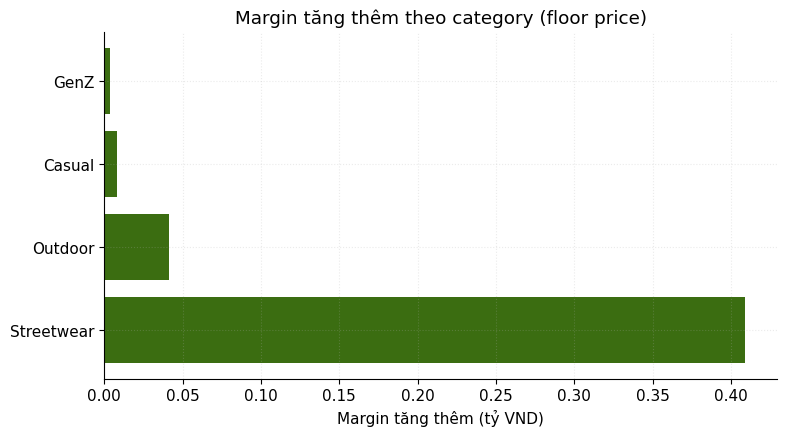

In [4]:
li_full = items.merge(products[["product_id", "category", "cogs", "price"]], on="product_id", how="left")
li_full["line_revenue"] = li_full["quantity"] * li_full["unit_price"]
li_full["line_cogs"] = li_full["quantity"] * li_full["cogs"]
li_full["unit_price_floor"] = np.maximum(li_full["unit_price"], li_full["cogs"])
li_full["line_revenue_floor"] = li_full["quantity"] * li_full["unit_price_floor"]

n_total = len(li_full)
n_below = (li_full["unit_price"] < li_full["cogs"]).sum()

rev_actual = li_full["line_revenue"].sum()
cogs_actual = li_full["line_cogs"].sum()
margin_actual_pct = (1 - cogs_actual / rev_actual) * 100
margin_actual_vnd = rev_actual - cogs_actual

rev_floor = li_full["line_revenue_floor"].sum()
margin_floor_pct = (1 - cogs_actual / rev_floor) * 100
margin_floor_vnd = rev_floor - cogs_actual
margin_gain_vnd = margin_floor_vnd - margin_actual_vnd
margin_gain_pp = margin_floor_pct - margin_actual_pct

print(f"Tổng dòng order_items (toàn bộ lịch sử): {n_total:,} | dưới giá vốn: {n_below:,} "
      f"({n_below/n_total*100:.2f}%)")
print(f"Margin thực tế: {margin_actual_pct:.2f}% ({margin_actual_vnd/1e9:.3f} tỷ VND)")
print(f"Margin nếu áp floor price = cogs: {margin_floor_pct:.2f}% ({margin_floor_vnd/1e9:.3f} tỷ VND)")
print(f"=> Margin tăng thêm: +{margin_gain_pp:.2f} điểm % , +{margin_gain_vnd/1e9:.3f} tỷ VND")

cat_g = li_full.groupby("category").agg(
    revenue=("line_revenue", "sum"), cogs=("line_cogs", "sum"),
    revenue_floor=("line_revenue_floor", "sum")).reset_index()
cat_g["margin_gain_vnd"] = ((cat_g["revenue_floor"] - cat_g["cogs"]) - (cat_g["revenue"] - cat_g["cogs"]))
cat_g = cat_g.sort_values("margin_gain_vnd", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(cat_g["category"], cat_g["margin_gain_vnd"] / 1e9, color=PALETTE[2])
ax.set_xlabel("Margin tăng thêm (tỷ VND)")
ax.set_title("Margin tăng thêm theo category (floor price)")
fig.tight_layout(); plt.show()


18.62% lịch sử dòng hàng bán dưới giá vốn. Áp sàn giá = giá vốn: margin 13.80%→16.15% (+0.462 tỷ VND), 88% đến từ riêng Streetwear.

## Đề xuất 2 — Win-back theo RFM segment

Build lại `rfm` (giống `02c`, cần cho việc này, không share state giữa notebook).

In [5]:
SNAPSHOT_DATE = orders["order_date"].max()
non_cancel = orders[orders["order_status"] != "cancelled"].merge(
    payments[["order_id", "payment_value"]], on="order_id", how="left")

rfm = non_cancel.groupby("customer_id").agg(
    last_order=("order_date", "max"),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum"),
).reset_index()
rfm["recency_days"] = (SNAPSHOT_DATE - rfm["last_order"]).dt.days

def qscore(s, labels):
    ranks = s.rank(method="first")
    return pd.qcut(ranks, 5, labels=labels).astype(int)

rfm["R_score"] = qscore(rfm["recency_days"], [5, 4, 3, 2, 1])
rfm["F_score"] = qscore(rfm["frequency"], [1, 2, 3, 4, 5])
rfm["M_score"] = qscore(rfm["monetary"], [1, 2, 3, 4, 5])

def rfm_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4: return "Champions"
    if r >= 3 and f >= 3 and m >= 3: return "Loyal Customers"
    if r >= 4 and f <= 2: return "New Customers"
    if r == 3 and f <= 2: return "Promising"
    if r <= 2 and f >= 4 and m >= 4: return "Can't Lose Them"
    if r <= 2 and f >= 3: return "At Risk"
    if r <= 2 and f <= 2 and m >= 3: return "Hibernating"
    if r <= 2 and f <= 2: return "Lost"
    return "Need Attention"

rfm["segment"] = rfm.apply(rfm_segment, axis=1)
seg_summary = (rfm.groupby("segment")
               .agg(n_customers=("customer_id", "count"),
                    total_monetary=("monetary", "sum"),
                    avg_recency=("recency_days", "mean"),
                    avg_frequency=("frequency", "mean"))
               .sort_values("total_monetary", ascending=False))
seg_summary["pct_customers"] = seg_summary["n_customers"] / seg_summary["n_customers"].sum() * 100
seg_summary["pct_monetary"] = seg_summary["total_monetary"] / seg_summary["total_monetary"].sum() * 100
seg_summary.round(2)


,n_customers,total_monetary,avg_recency,avg_frequency,pct_customers,pct_monetary
segment,,,,,,
Champions,22575,8.949596e+09,274.23,15.88,25.62,62.88
Loyal Customers,16974,2.884125e+09,787.01,7.02,19.26,20.26
At Risk,7989,6.461639e+08,2009.51,3.90,9.07,4.54
Can't Lose Them,2251,4.920698e+08,1782.76,8.61,2.55,3.46
Lost,21682,4.587557e+08,2562.65,1.26,24.60,3.22
Hibernating,3327,2.696038e+08,2398.74,1.60,3.78,1.89
Promising,5375,2.054179e+08,1105.38,1.48,6.10,1.44
New Customers,4865,2.033228e+08,359.00,1.51,5.52,1.43
Need Attention,3085,1.248016e+08,688.95,3.65,3.50,0.88


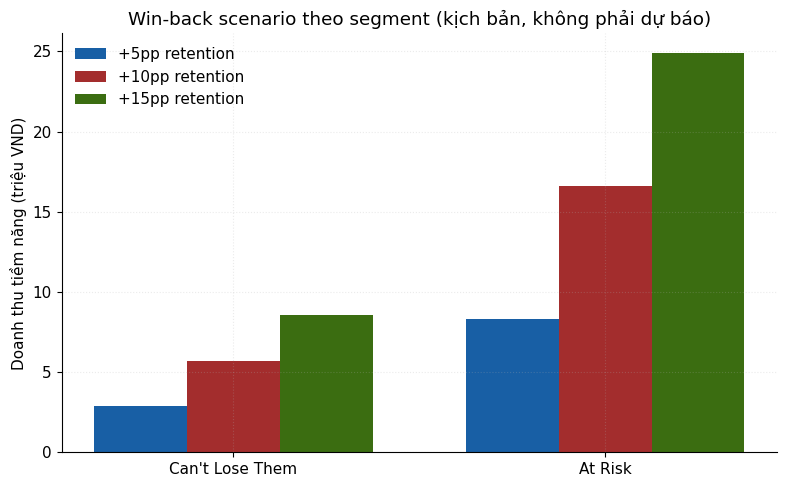

,segment,n_customers,avg_order_value_vnd,uplift_scenario_pct,n_customers_retained_est,revenue_potential_vnd
0,Can't Lose Them,2251,25393.2,5.0,112.6,2858006.9
1,Can't Lose Them,2251,25393.2,10.0,225.1,5716013.8
2,Can't Lose Them,2251,25393.2,15.0,337.6,8574020.7
3,At Risk,7989,20756.3,5.0,399.5,8291098.0
4,At Risk,7989,20756.3,10.0,798.9,16582196.1
5,At Risk,7989,20756.3,15.0,1198.4,24873294.1


In [6]:
target_segments = ["Can't Lose Them", "At Risk"]
uplift_scenarios = [0.05, 0.10, 0.15]  # kịch bản +X điểm % retention, KHÔNG phải dự báo

rows = []
for seg in target_segments:
    sub = rfm[rfm["segment"] == seg]
    n_cust = len(sub)
    total_monetary = sub["monetary"].sum()
    total_frequency = sub["frequency"].sum()
    aov = total_monetary / total_frequency if total_frequency else np.nan
    for x in uplift_scenarios:
        n_retained = n_cust * x
        revenue_potential = n_retained * aov
        rows.append({"segment": seg, "n_customers": n_cust, "avg_order_value_vnd": aov,
                     "uplift_scenario_pct": x * 100, "n_customers_retained_est": n_retained,
                     "revenue_potential_vnd": revenue_potential})
winback = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 5))
width = 0.25
x_pos = np.arange(len(target_segments))
for i, x in enumerate(uplift_scenarios):
    vals = [winback[(winback.segment == s) & (winback.uplift_scenario_pct == x*100)]["revenue_potential_vnd"].values[0] / 1e6
            for s in target_segments]
    ax.bar(x_pos + i*width, vals, width=width, label=f"+{x*100:.0f}pp retention", color=PALETTE[i])
ax.set_xticks(x_pos + width); ax.set_xticklabels(target_segments)
ax.set_ylabel("Doanh thu tiềm năng (triệu VND)")
ax.set_title("Win-back scenario theo segment (kịch bản, không phải dự báo)")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()
winback.round(1)


Kịch bản lạc quan nhất (+15pp retention) chỉ mang lại ~33.4 triệu VND — 0.20% doanh thu 10 năm. Giá trị thật nằm ở thử nghiệm rẻ, không phải đòn bẩy tài chính lớn.

## Đề xuất 3 — Đồng bộ pricing theo vùng

Margin toàn phần theo region: {'West': 14.2, 'East': 13.31, 'Central': 13.15}
Vùng margin tốt nhất: West

Giả định: các vùng còn lại đạt 60% khoảng cách margin so với 'West' trong cùng category
Margin toàn shop hiện tại: 13.47%
=> Tổng margin tăng thêm: +0.038 tỷ VND
=> Margin toàn shop mới: 13.71% (+0.24 điểm %)


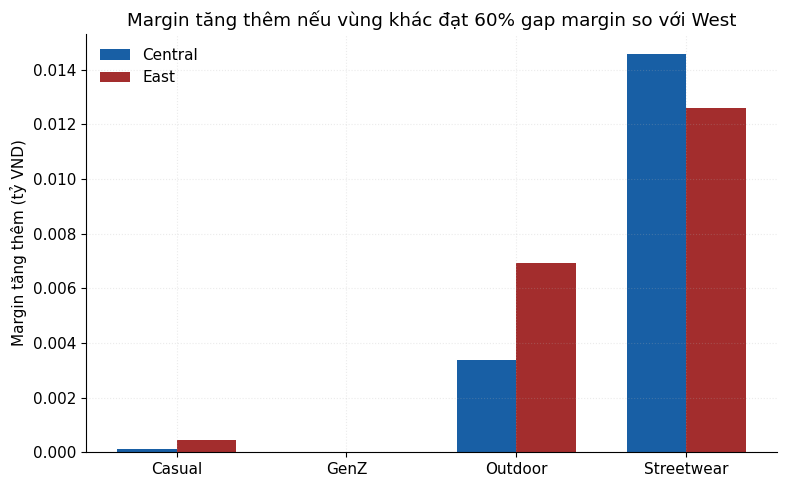

In [7]:
rc = li.groupby(["region", "category"]).agg(revenue=("line_revenue", "sum"), cogs=("line_cogs", "sum")).reset_index()
rc["margin_pct"] = (rc["revenue"] - rc["cogs"]) / rc["revenue"] * 100
region_margin_overall = li.groupby("region").apply(
    lambda g: (g["line_revenue"].sum() - g["line_cogs"].sum()) / g["line_revenue"].sum() * 100,
    include_groups=False).sort_values(ascending=False)
BEST_REGION = region_margin_overall.index[0]
print("Margin toàn phần theo region:", region_margin_overall.round(2).to_dict())
print(f"Vùng margin tốt nhất: {BEST_REGION}")

PRICE_EFFECT_SHARE = 0.60  # giả định ~60% chênh lệch margin do giá thật tốt hơn (Phase 2 Q3)
best = rc[rc.region == BEST_REGION].set_index("category")["margin_pct"]

rows3 = []
for reg in [r for r in rc["region"].unique() if r != BEST_REGION]:
    sub = rc[rc.region == reg].copy()
    sub["best_region_margin_pct"] = sub["category"].map(best)
    sub["gap_pp"] = sub["best_region_margin_pct"] - sub["margin_pct"]
    sub["gap_pp_positive"] = sub["gap_pp"].clip(lower=0)
    sub["target_margin_pct"] = sub["margin_pct"] + PRICE_EFFECT_SHARE * sub["gap_pp_positive"]
    sub["cogs_new"] = sub["revenue"] * (1 - sub["target_margin_pct"] / 100)
    sub["margin_gain_vnd"] = sub["cogs"] - sub["cogs_new"]
    rows3.append(sub)
repl = pd.concat(rows3, ignore_index=True)

total_gain = repl["margin_gain_vnd"].sum()
total_revenue_all = rc["revenue"].sum()
total_cogs_all = rc["cogs"].sum()
margin_pct_before = (1 - total_cogs_all / total_revenue_all) * 100
margin_pct_after = (1 - (total_cogs_all - total_gain) / total_revenue_all) * 100

print(f"\nGiả định: các vùng còn lại đạt {PRICE_EFFECT_SHARE*100:.0f}% khoảng cách margin so với "
      f"'{BEST_REGION}' trong cùng category")
print(f"Margin toàn shop hiện tại: {margin_pct_before:.2f}%")
print(f"=> Tổng margin tăng thêm: +{total_gain/1e9:.3f} tỷ VND")
print(f"=> Margin toàn shop mới: {margin_pct_after:.2f}% (+{margin_pct_after-margin_pct_before:.2f} điểm %)")

fig, ax = plt.subplots(figsize=(8, 5))
cats = repl["category"].unique()
x_pos = np.arange(len(cats))
regions_other = repl["region"].unique()
width = 0.35
for i, reg in enumerate(regions_other):
    vals = [repl[(repl.category == c) & (repl.region == reg)]["margin_gain_vnd"].values[0] / 1e9
            for c in cats]
    ax.bar(x_pos + i*width, vals, width=width, label=reg, color=PALETTE[i])
ax.set_xticks(x_pos + width/2); ax.set_xticklabels(cats)
ax.set_ylabel("Margin tăng thêm (tỷ VND)")
ax.set_title(f"Margin tăng thêm nếu vùng khác đạt {PRICE_EFFECT_SHARE*100:.0f}% gap margin so với {BEST_REGION}")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()


Chênh margin giữa vùng chỉ ~1 điểm % (West 14.2% vs Central 13.1%) — kịch bản đồng bộ giá vùng chỉ thu thêm 0.038 tỷ VND, nhỏ hơn 12 lần so với floor-pricing.

## Hạn chế của phân tích (toàn notebook)

- Dữ liệu là **e-commerce mô phỏng** (không phải giao dịch thật) — số tuyệt đối không đại diện
  thị trường thật, chỉ dùng để luyện kỹ năng phân tích/pipeline.
- Đọc trực tiếp **raw CSV** qua `datathon.config` (M3a/M3b dbt marts CHƯA xong tại thời điểm viết
  — xem `PROCESS.md`). Khi mart xong, cần re-run và đối chiếu số liệu không đổi (regression).
- Phần Diagnostic dùng **quan sát tương quan** (vd promo vs below-cost, promo vs Tết dip) — KHÔNG
  chứng minh nhân quả; mẫu Tết chỉ 10 năm, corr chỉ mang tính gợi ý.
- Phần Prescriptive là **kịch bản what-if tĩnh** trên dữ liệu lịch sử (elasticity giá/nhu cầu
  không được model — floor price giả định khách vẫn mua đúng volume cũ dù giá tăng; win-back giả
  định tỷ lệ quay lại; nhân rộng pricing giả định margin gap không có nguyên nhân cấu trúc khác
  ngoài giá) — cần thử nghiệm A/B thật trước khi triển khai diện rộng.
- Bỏ qua phần logistic-regression churn model (dashboard gốc `customer_demographics.py` mục 28) —
  ngoài phạm vi "descriptive/diagnostic/dashboard/prescriptive" của M6a; vẫn còn nguyên trong
  `docs/analysis/phase3_dashboard/` nếu cần tham khảo.

## Đề xuất tiếp theo

1. Khi M3b xong: chuyển mục 0 sang đọc `iceberg.marts.*` qua Trino, verify số liệu KHÔNG đổi.
2. A/B test floor price trên 1-2 category có margin_gain_vnd cao nhất trước khi áp toàn shop.
3. Chiến dịch win-back nhắm đúng `Can't Lose Them` trước (Monetary/khách cao nhất trong 2 segment
   rủi ro) — đo lường bằng uplift thật (test/control), không dùng số kịch bản ở trên làm KPI cam kết.
